# Modeling Intro: First RGB Barycentric Triangle

## Introduction

This notebook starts with code that already works and produces a meaningful result. That is often exactly what we need in science: something correct enough to explore an idea. We start with writing code in Jupyter notebooks because it is quick and easy for the programmer.

In CMSE 802, we build from that success by adding a few software engineering habits that are:

- quick to apply
- easy to understand
- high impact for readability and reuse

The goal is to build from a working concept and make code that is [***Safe, Portable, Reproducible, Robust and Literate***](https://colbrydi.github.io/Research_guidelines/Rules_for_Repos.html).

## What To Do

1. Run the code cell below to generate the triangle image.
2. Work with your team to understand what the code is doing.
3. Make one small change.
4. Re-run the code cell.
5. Observe what changed.
6. Discuss why the change helps.

In [1]:
## added in class by dirk
%load_ext autoreload
%autoreload 2 

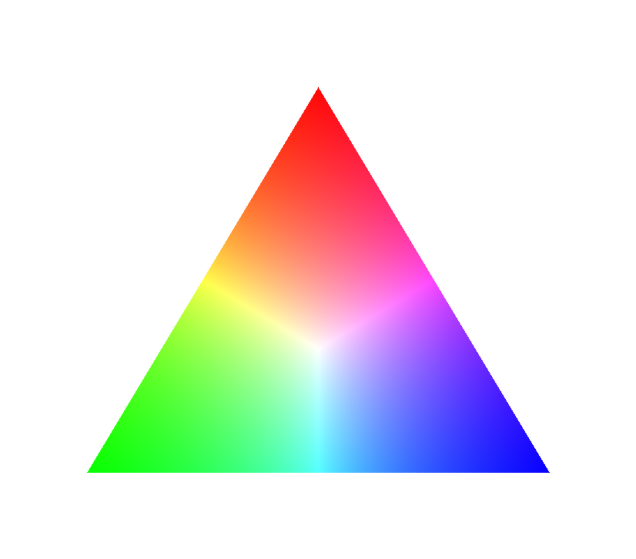

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Image size
width = 800
height = 700

# Create empty RGB image initialized to white
image = np.ones((height, width, 3), dtype=float)

# Triangle vertices
red_point = np.array([width / 2, 100])          # top
green_point = np.array([100, height - 100])     # bottom left
blue_point = np.array([width - 100, height - 100])  # bottom right


def point_in_triangle(p, a, b, c):
    """
    Return True if point p is inside triangle abc.
    Uses barycentric coordinates.
    """
    v0 = c - a
    v1 = b - a
    v2 = p - a

    dot00 = np.dot(v0, v0)
    dot01 = np.dot(v0, v1)
    dot02 = np.dot(v0, v2)
    dot11 = np.dot(v1, v1)
    dot12 = np.dot(v1, v2)

    denom = dot00 * dot11 - dot01 * dot01

    u = (dot11 * dot02 - dot01 * dot12) / denom
    v = (dot00 * dot12 - dot01 * dot02) / denom

    return (u >= 0) and (v >= 0) and (u + v <= 1)


# Maximum possible distance inside triangle
max_dist = max(
    np.linalg.norm(red_point - green_point),
    np.linalg.norm(red_point - blue_point),
    np.linalg.norm(green_point - blue_point),
)

# Loop through every pixel
for y in range(height):
    for x in range(width):

        p = np.array([x, y])

        if point_in_triangle(
            p,
            red_point,
            green_point,
            blue_point
        ):

            d_red = np.linalg.norm(p - red_point)
            d_green = np.linalg.norm(p - green_point)
            d_blue = np.linalg.norm(p - blue_point)

            # Convert distances into "closeness"
            r = 1.0 - d_red / max_dist
            g = 1.0 - d_green / max_dist
            b = 1.0 - d_blue / max_dist

            color = np.array([r, g, b])

            # Normalize so colors remain vivid
            color /= color.max()

            image[y, x] = color

# Display result
plt.figure(figsize=(8, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

## Notes on the improved code

*AI use: explaining the code and reviewing changes*

### What the code does

The image is a grid of 800 × 700 pixels. Each pixel holds three numbers (red, green, blue) between 0 and 1, and the grid starts all white.

1. `triangle_vertices` sets the three corners: red at the top, green bottom left, blue bottom right. In images y counts downward, so a large y is near the bottom.
2. `point_in_triangle` asks one pixel a yes-or-no question: are you inside the triangle?
3. `plot_triangle` checks every pixel. Outside pixels stay white. Inside pixels get more red the closer they are to the red corner, and the same for green and blue. The strongest color is then scaled up to 1 so the image looks bright.
4. `add_project_point` turns my three scores into a location by mixing the corner positions: position = A × red corner + P × green corner + D × blue corner. The scores must add to 1, and the `assert` stops the code with a clear message if they don't.
5. The last block draws the triangle, labels the corners, adds RANGE at A = 0.6, P = 0.25, D = 0.15, and saves the figure.

### How the code answers each exercise

| Exercise | What I changed |
|---|---|
| 1. Magic numbers | `border` replaces every hard-coded 100. `WIDTH`, `HEIGHT` and `BORDER` are set once in the last block. |
| 2. Script to function | `plot_triangle(width=800, height=700, border=100, filename=None)` has default values and returns the image array. |
| 3. Project point | `add_project_point(analytical, physical, data_driven, ...)` draws a labeled dot on top of the triangle. |
| 4. Save the figure | Saving is optional through `filename`. The default `None` means no file is saved. |
| 5. Literate code | Docstrings on every function, comments that explain why, one shared function for the corners, a clear error if the scores don't add to 1, and a check for a flat triangle (`denom == 0`). |

### Things to keep in mind

- The colors are not the true A/P/D mix. They come from distance to each corner and are rescaled for looks. The dot uses the real mixing formula, so the color under the dot is not exactly its A/P/D value.
- Order matters. `plot_triangle` creates the figure and everything after it draws on top. That is why the RANGE figure is saved at the end with `plt.savefig` instead of through `filename=`, which would save before the labels and dot exist.
- `add_project_point` must get the same `width`, `height` and `border` as `plot_triangle`, or the dot lands in the wrong place. Nothing in the code enforces this.
- The loop visits 560,000 pixels one at a time, so each triangle takes a few seconds. NumPy could do this without a loop.

### What I would do next

- Have `plot_triangle` return the corners so `add_project_point` can reuse them directly.
- Compute the dot products that depend only on the triangle once, not once per pixel.

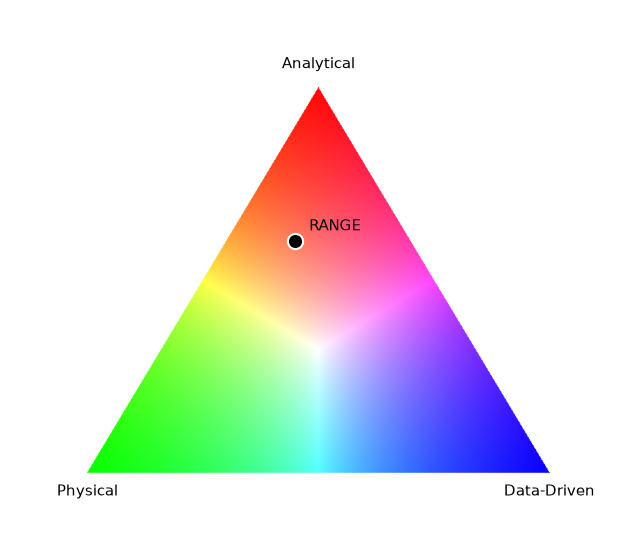

In [3]:
### IMPROVED VERSION

import numpy as np
import matplotlib.pyplot as plt

# WHY: answers one yes-or-no question for a single pixel: are you inside those three corners?
# rewrite the pixel's position as a mix of the two edges leaving corner a; if both mixing weights are positive and sum to no more than 1, the pixel is inside.
def point_in_triangle(p, a, b, c):
    """
    Return True if point p is inside triangle abc.
    Uses barycentric coordinates.
    """
    # Two edges leaving corner a, and the vector from a out to our pixel p.
    v0 = c - a  # edge a -> c
    v1 = b - a  # edge a -> b
    v2 = p - a  # a -> the pixel we are testing

    # Dot products. Three describe only the triangle's shape, so they're the same for every pixel. 
    # the two that use v2 change with the pixel being tested.
    dot00 = np.dot(v0, v0)
    dot01 = np.dot(v0, v1)
    dot02 = np.dot(v0, v2)
    dot11 = np.dot(v1, v1)
    dot12 = np.dot(v1, v2)

    # Shared divisor. It is zero only if the three corners are in a
    # straight line, i.e. the triangle has no area.
    denom = dot00 * dot11 - dot01 * dot01

    if denom == 0:          # Ex 5 / robust: degenerate triangle
        return False

    # u and v answer: how much of edge a->c and edge a->b do we need
    # to walk from a to reach p?
    u = (dot11 * dot02 - dot01 * dot12) / denom
    v = (dot00 * dot12 - dot01 * dot02) / denom

    # Inside means: neither step goes backwards (both >= 0), and together
    # they do not overshoot past the far edge (u + v <= 1).
    return (u >= 0) and (v >= 0) and (u + v <= 1)


# plot_triangle and add_project_point both need the same three corners. 
# Computing them in two places means they can drift apart — change the border in one and the point lands in the wrong spot. 
# One function, one definition, both callers stay in sync.


# WHY: decides where the three corners sit on a blank canvas — red top, green bottom-left, blue bottom-right.
def triangle_vertices(width, height, border):
    """Return the (red, green, blue) corner pixels for a given canvas.

    Red is the top corner, green bottom-left, blue bottom-right.
    `border` is the white margin in pixels around the triangle.
    """
    # Pixel coordinates are [x, y] and y grows DOWNWARD, so a small y is near the top of the image and a large y is near the bottom.
    red_point = np.array([width / 2, border])              # top: centred, border down from the top
    green_point = np.array([border, height - border])      # bottom left: border in, border up
    blue_point = np.array([width - border, height - border])  # bottom right: border in from the right
    return red_point, green_point, blue_point

# WHY: walks over all 560,000 pixels. Outside ones stay white. Inside ones get a colour based on which corner they are closest to, so the triangle fades smoothly from red to green to blue
def plot_triangle(width=800, height=700, border=100, filename=None):
    """Draw an RGB barycentric triangle and return the image array.

    Args:
        width, height: canvas size in pixels.
        border: white margin in pixels around the triangle.
        filename: if given, save the figure to this path. If None, do not save.

    Returns:
        The (height, width, 3) float image array.
    """
    # Ex 1: no magic numbers. border replaces every hard-coded 100.
    image = np.ones((height, width, 3), dtype=float)
    # Corners come from one shared function, so they can never drift apart.
    red_point, green_point, blue_point = triangle_vertices(width, height, border)

    # Longest side of the triangle. Used as the yardstick that turns a raw
    # distance into a 0-to-1 value, so no channel can go negative.
    max_dist = max(
        np.linalg.norm(red_point - green_point),
        np.linalg.norm(red_point - blue_point),
        np.linalg.norm(green_point - blue_point),
    )
    # Visit every pixel in the image, one at a time.
    for y in range(height):
        for x in range(width):
            p = np.array([x, y])
            # Pixels outside the triangle are skipped, so they stay white.
            if point_in_triangle(p, red_point, green_point, blue_point):
                # How far this pixel sits from each of the three corners.
                d_red = np.linalg.norm(p - red_point)
                d_green = np.linalg.norm(p - green_point)
                d_blue = np.linalg.norm(p - blue_point)
                
                # Turn distance into "closeness" to each corner
                # Near a corner -> small distance -> value near 1 -> strong colour.
                color = np.array([
                    1.0 - d_red / max_dist,
                    1.0 - d_green / max_dist,
                    1.0 - d_blue / max_dist,
                ])

                # Rescale for appearance only, not true barycentric weights
                # Forces the strongest channel to exactly 1.0 so the figure
                # looks vivid instead of washed out grey.
                color /= color.max()

                image[y, x] = color
    
    # Display: no axes, since pixel numbers mean nothing to the reader.
    plt.figure(figsize=(8, 7))
    plt.imshow(image)
    plt.axis("off")

    # Ex 4: saving is controlled by an argument, not always or never
    if filename is not None:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    # Ex 2: hand back the array so other code can reuse it, not just look at it.
    return image

# WHY: takes your three scores, which must add to 1, and turns them into a pixel position by blending the corners. It draws a dot there.
def add_project_point(analytical, physical, data_driven,
                      width=800, height=700, border=100,
                      color="black", size=120, label=None):
    """Plot a research project as a point inside the triangle.

    The three scores are proportions that must sum to 1. They are converted
    to a pixel position by weighting the three corners.

    Args:
        analytical, physical, data_driven: proportions summing to 1 (red, green, blue).
        width, height, border: must match the values used for plot_triangle.
        color, size, label: optional styling.
    """

    # Catch the mistake early and say what went wrong. Without this, scores
    # that don't sum to 1 still plot, just silently in the wrong place.
    total = analytical + physical + data_driven
    assert np.isclose(total, 1.0), f"Scores must sum to 1, got {total}"

    # Same three corners the background used, from the same function.
    red_point, green_point, blue_point = triangle_vertices(width, height, border)

    # Weighted average of the corners: this is the real barycentric conversion
    # All-analytical lands exactly on the red corner; equal thirds land in
    # the middle. The scores summing to 1 is what keeps the point inside.
    position = (analytical * red_point
                + physical * green_point
                + data_driven * blue_point)

    # zorder=3 draws the dot above the image; the white edge keeps it visible
    # no matter what colour the triangle is underneath it.
    plt.scatter(position[0], position[1], c=color, s=size,
                edgecolors="white", linewidths=1.5, zorder=3, label=label)
    # Label is optional, so only draw it when one was given.
    if label is not None:
        plt.annotate(label, (position[0], position[1]),
                     textcoords="offset points", xytext=(10, 8), fontsize=11)
    # Hand back the pixel position in case the caller wants it.
    return position


#WHY LAST BLOCK: The last block runs all of it: draw the triangle, label the corners, plot RANGE at 0.6 / 0.25 / 0.15, save the file.

# Run it: RANGE sits at A=0.6, P=0.25, D=0.15
# Defined once here so the background and the point cannot disagree
WIDTH, HEIGHT, BORDER = 800, 700, 100

# Draw the triangle. This also creates the figure that everything below
# adds onto, so it has to come first.
image = plot_triangle(width=WIDTH, height=HEIGHT, border=BORDER)


# Label each corner so a reader knows which colour means what.
# The offsets (-25, +30) nudge the text clear of the corner itself.
plt.text(WIDTH / 2, BORDER - 25, "Analytical", ha="center", fontsize=11)
plt.text(BORDER, HEIGHT - BORDER + 30, "Physical", ha="center", fontsize=11)
plt.text(WIDTH - BORDER, HEIGHT - BORDER + 30, "Data-Driven", ha="center", fontsize=11)

# My RANGE project: mostly analytical, some physical, least data-driven.
# Same WIDTH/HEIGHT/BORDER, so the dot lands on the triangle just drawn.
add_project_point(0.6, 0.25, 0.15,
                  width=WIDTH, height=HEIGHT, border=BORDER,
                  label="RANGE")

# Save after everything is drawn, otherwise the file misses the labels
# and the point.
plt.savefig("model_triangle_range.png", dpi=150, bbox_inches="tight")
plt.show()


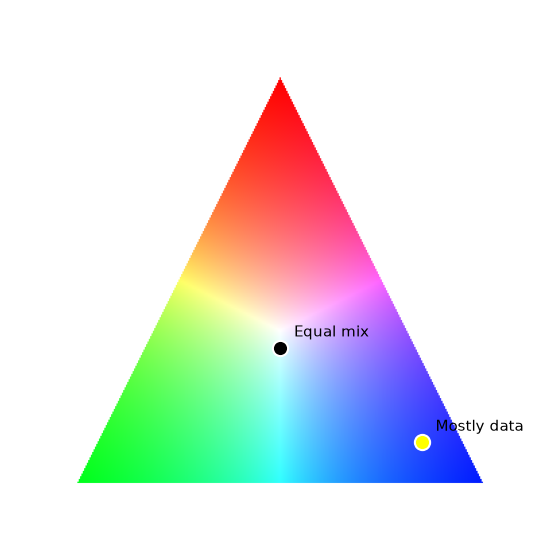

In [4]:
# Trying different inputs (Exercises 1-3)
# Functions defined in the IMPROVED VERSION cell above, so this cell only calls them with new values

# Ex 1 and 2: a smaller canvas and a thinner white border
# Set once here so the triangle and both dots use the same size.
W, H, B = 400, 400, 50   # width, height, border (in pixels)

# Draw the triangle at the new size. This creates the figure that the dots below are drawn on top of, so it has to come first
plot_triangle(width=W, height=H, border=B)

# Ex 3: add two different projects
# Scores are (analytical, physical, data_driven) and must add to 1.

# Equal thirds, so this dot should land in the middle of the triangle
add_project_point(1/3, 1/3, 1/3, width=W, height=H, border=B,label="Equal mix")

# Mostly data-driven (0.8), so this dot should land near the blue corner.
# Yellow with a different label, to try a different style.
add_project_point(0.1, 0.1, 0.8, width=W, height=H, border=B,color="yellow", label="Mostly data")

# Show the finished figure: triangle plus both dots
plt.show()

# Improving the Triangle Generator

The code currently works and produces a useful figure.

In this section, your goal is not to change the overall behavior of the program. Instead, you will make a series of small improvements that make the code easier to understand, modify, reuse, and maintain.

As you work through these exercises, think about how your changes contribute to software that is:

- Safe
- Portable
- Reproducible
- Robust
- Literate

After each change, run the code and verify that it still produces a valid figure.

## Exercise 1: Eliminate Magic Numbers

Find the hard-coded values that define the border around the triangle.

Create a variable named:

```python
border
```

and replace the repeated raw values with the new variable.

Experiment with different values of `border` and observe how the figure changes.

### Team/Class Reflection
- What does the border represent?
- Why is a named variable easier to understand than a raw number?
- How might this change make the code more robust?
- Are there any other magic numbers we should define as variables?
- How could you eliminate magic numbers without a variable?

## Exercise 2: Convert the Script to a Function

The current code executes from top to bottom as a script. Now we want to make it more portable by turning it into a function:

- Refactor the code into a function using `def` that generates the triangle.
- Choose a set of inputs that would be useful to another programmer.
- Provide reasonable default values.

Test your function using several different inputs.

### Team/Class Reflection

- What did you name your function? Is the name useful?
- Which values belong as function inputs?
- Which values should remain internal details?
- How do default arguments make software easier to use?
- How might this help make the code more portable?

## Exercise 3: Add a Project Point

Create a new function that adds a point somewhere inside the triangle. The point should be displayed on top of the generated image. Experiment with different locations and styles.

Imagine this point represents your research project positioned within the RGB framework where RGB is:

- Red = Analytical
- Green = Physical
- Blue = Data-Driven

### Team/Class Reflection

- What did you name your new function? Is the name useful?
- What information should the function require?
- What information could be optional?
- Would another student understand how to use your function?

## Exercise 4: Save the Figure

Modify the code so a user can save the generated figure to a file.

Consider whether saving should always happen, never happen, or be controlled through a function argument.

Adjust your implementation.

### Team/Class Reflection

- Why is saving generated figures useful in research?
- How can saved figures support reproducible workflows?
- What file naming practices might help keep projects organized?

## Exercise 5: Make the Code More Literate

Imagine another student needs to use your code next semester.

Improve the code so it is easier to understand.

Possible ideas include:

- better variable names
- add comments and docstrings
- clearer function names

### Team/Class Reflection

- What change did you make?
- How does it improve readability?
- How does it support literate software?

You are done with this notebook. Move on to the next notebook to learn how to make your code more portable using a Python library.